# Collect Motor Dataset

This notebook sends configurable excitation signals to one motor and saves one CSV per continuous run in the format expected by `dataset_format.md`:

```text
time_s,qpos,qvel,qact
```

`qact` is the exact command sequence passed to `SignalGenerator.play_signal`. `qpos` is unwrapped on the host from the raw decoded `[-10, 10]` rad feedback. During `collect_all`, the first measured position of the first run is used as the shared zero, so later runs keep their physical offset relative to the initial manual zero.

In [1]:
from dataclasses import dataclass
from pathlib import Path
import sys
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SCRIPT_DIR = Path.cwd() if Path.cwd().name == "scripts" else Path.cwd() / "scripts"
if str(SCRIPT_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPT_DIR))

from motor_position import unwrap_motor_position

import encosid

/home/slava/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Configuration

Set the CAN interface, motor id, sample period, output directory, and command safety limit before running collection. The default collection cell is guarded by `RUN_COLLECTION = False`; change it only when the motor is mechanically safe.

In [2]:
MOTOR_IF = "can0"
MOTOR_ID = 3

DT_MS = 1

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "scripts" else Path.cwd()
OUTPUT_DIR = PROJECT_ROOT / "data" / "raw"

# `qact` is the raw command sent to the motor. In torque mode this is the
# torque-command argument of `hybridControl`, not a position target in radians.
CONTROL_MODE = "torque"
MODE_GAIN = 0.0

# Hardware encoding supports qact in [-90, 90] and qvel feedback in [-20, 20].
# Start conservatively and raise this only after checking coverage/saturation plots.
MAX_ABS_COMMAND = 30.0
QVEL_FEEDBACK_LIMIT = 20.0
QVEL_WARNING_LIMIT = 18.0

RUN_COLLECTION = True


@dataclass(frozen=True)
class RunSpec:
    name: str
    kind: str
    duration_s: float
    amplitude: float
    f_hz: float | None = None
    f0_hz: float | None = None
    f1_hz: float | None = None
    step_s: float | None = None
    pulse_s: float | None = None
    seed: int | None = None


RUN_PLAN = [
    # Chirps are good at sweeping through broad velocity ranges.
    RunSpec(name="chirp_0p1_2hz_amp10", kind="chirp", duration_s=20.0, amplitude=4.0, f0_hz=0.1, f1_hz=2.0),
    # RunSpec(name="chirp_0p1_4hz_amp20", kind="chirp", duration_s=12.0, amplitude=20.0, f0_hz=0.1, f1_hz=4.0),

    # # Short random steps fill the local (qvel, qact) field more densely than long sines.
    # RunSpec(name="steps_amp10_20ms_s1", kind="random_steps", duration_s=10.0, amplitude=10.0, step_s=0.02, seed=1),
    # RunSpec(name="steps_amp20_20ms_s2", kind="random_steps", duration_s=10.0, amplitude=20.0, step_s=0.02, seed=2),
    # RunSpec(name="steps_amp30_50ms_s3", kind="random_steps", duration_s=10.0, amplitude=30.0, step_s=0.05, seed=3),

    # # Pulse trains allow higher torque samples without holding large torque for long.
    # RunSpec(name="pulses_amp30_10ms_100ms_s4", kind="random_pulses", duration_s=10.0, amplitude=30.0, step_s=0.10, pulse_s=0.01, seed=4),
]

In [3]:
def time_axis(duration_s: float, dt_ms: float = DT_MS) -> np.ndarray:
    sample_count = int(round(duration_s * 1000 / dt_ms))
    return np.arange(sample_count, dtype=float) * dt_ms * 1e-3


def require_value(value: float | None, field_name: str, spec: RunSpec) -> float:
    if value is None:
        raise ValueError(f"{spec.name} requires {field_name}")
    return value


def sine_signal(t: np.ndarray, amplitude: float, f_hz: float) -> np.ndarray:
    return amplitude * np.sin(2 * np.pi * f_hz * t)


def chirp_signal(t: np.ndarray, amplitude: float, f0_hz: float, f1_hz: float) -> np.ndarray:
    if len(t) == 0:
        return np.array([], dtype=float)
    duration_s = t[-1] + (t[1] - t[0] if len(t) > 1 else DT_MS * 1e-3)
    sweep_rate = (f1_hz - f0_hz) / duration_s
    phase = 2 * np.pi * (f0_hz * t + 0.5 * sweep_rate * t**2)
    return amplitude * np.sin(phase)


def random_step_signal(
    t: np.ndarray,
    amplitude: float,
    step_s: float,
    seed: int | None = None,
) -> np.ndarray:
    rng = np.random.default_rng(seed)
    if len(t) == 0:
        return np.array([], dtype=float)
    dt_s = t[1] - t[0] if len(t) > 1 else DT_MS * 1e-3
    samples_per_step = max(1, int(round(step_s / dt_s)))
    step_count = int(np.ceil(len(t) / samples_per_step))
    levels = rng.uniform(-amplitude, amplitude, size=step_count)
    return np.repeat(levels, samples_per_step)[: len(t)]


def random_pulse_signal(
    t: np.ndarray,
    amplitude: float,
    period_s: float,
    pulse_s: float,
    seed: int | None = None,
) -> np.ndarray:
    rng = np.random.default_rng(seed)
    if len(t) == 0:
        return np.array([], dtype=float)
    if pulse_s <= 0 or period_s <= 0 or pulse_s > period_s:
        raise ValueError("pulse_s must be positive and no larger than period_s")

    dt_s = t[1] - t[0] if len(t) > 1 else DT_MS * 1e-3
    samples_per_period = max(1, int(round(period_s / dt_s)))
    samples_per_pulse = max(1, int(round(pulse_s / dt_s)))
    period_count = int(np.ceil(len(t) / samples_per_period))
    levels = rng.uniform(-amplitude, amplitude, size=period_count)

    signal = np.zeros_like(t)
    for period_idx, level in enumerate(levels):
        start = period_idx * samples_per_period
        stop = min(start + samples_per_pulse, len(signal))
        signal[start:stop] = level
    return signal


def build_signal(spec: RunSpec, dt_ms: float = DT_MS) -> tuple[np.ndarray, np.ndarray]:
    t = time_axis(spec.duration_s, dt_ms)

    if spec.kind == "sine":
        signal = sine_signal(t, spec.amplitude, require_value(spec.f_hz, "f_hz", spec))
    elif spec.kind == "chirp":
        signal = chirp_signal(
            t,
            spec.amplitude,
            require_value(spec.f0_hz, "f0_hz", spec),
            require_value(spec.f1_hz, "f1_hz", spec),
        )
    elif spec.kind == "random_steps":
        signal = random_step_signal(t, spec.amplitude, require_value(spec.step_s, "step_s", spec), spec.seed)
    elif spec.kind == "random_pulses":
        signal = random_pulse_signal(
            t,
            spec.amplitude,
            require_value(spec.step_s, "step_s", spec),
            require_value(spec.pulse_s, "pulse_s", spec),
            spec.seed,
        )
    else:
        raise ValueError(f"Unsupported signal kind: {spec.kind}")

    signal = np.asarray(signal, dtype=float)
    if np.max(np.abs(signal), initial=0.0) > MAX_ABS_COMMAND:
        raise ValueError(
            f"{spec.name} exceeds MAX_ABS_COMMAND={MAX_ABS_COMMAND}: "
            f"max abs command is {np.max(np.abs(signal)):.3f}"
        )

    return t, signal

In [4]:
for spec in RUN_PLAN:
    t, qact = build_signal(spec)
    print(
        f"{spec.name}: {len(qact)} samples, "
        f"{t[-1] + DT_MS * 1e-3:.3f} s, "
        f"qact range [{qact.min():.3f}, {qact.max():.3f}]"
    )

chirp_0p1_2hz_amp10: 20000 samples, 20.000 s, qact range [-4.000, 4.000]


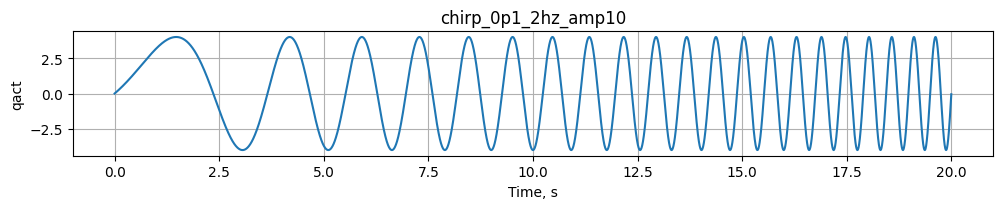

In [5]:
fig, ax = plt.subplots(len(RUN_PLAN), 1, figsize=(10, 2.2 * len(RUN_PLAN)), sharex=False)
if len(RUN_PLAN) == 1:
    ax = [ax]

for axis, spec in zip(ax, RUN_PLAN):
    t, qact = build_signal(spec)
    axis.plot(t, qact)
    axis.set_title(spec.name)
    axis.set_xlabel("Time, s")
    axis.set_ylabel("qact")
    axis.grid()

plt.tight_layout()
plt.show()

In [6]:
def set_generator_mode(gen: encosid.SignalGenerator, mode_name: str, mode_gain: float) -> None:
    modes = {
        "torque": gen.mode.torque,
        "position": gen.mode.position,
        "velocity": gen.mode.velocity,
    }
    try:
        mode = modes[mode_name]
    except KeyError as exc:
        raise ValueError(f"Unsupported CONTROL_MODE: {mode_name}") from exc
    gen.set_mode(mode, mode_gain)


def response_to_frame(
    t: np.ndarray,
    qact: np.ndarray,
    response,
    qpos_zero: float | None = None,
) -> tuple[pd.DataFrame, float]:
    qpos_raw, qvel, _qcur = map(lambda values: np.asarray(values, dtype=float), response)
    qpos = unwrap_motor_position(qpos_raw)
    if qpos_zero is None:
        if len(qpos) == 0:
            raise ValueError("Cannot infer qpos_zero from an empty response")
        qpos_zero = float(qpos[0])
    qpos = qpos - qpos_zero
    if not (len(t) == len(qact) == len(qpos) == len(qvel)):
        raise ValueError(
            "Signal and response lengths differ: "
            f"time={len(t)}, qact={len(qact)}, qpos={len(qpos)}, qvel={len(qvel)}"
        )

    return pd.DataFrame(
        {
            "time_s": t,
            "qpos": qpos,
            "qvel": qvel,
            "qact": qact,
        }
    ), qpos_zero


def report_velocity_saturation(df: pd.DataFrame, run_name: str) -> None:
    abs_qvel = df["qvel"].abs()
    near_limit = abs_qvel >= QVEL_WARNING_LIMIT
    print(
        f"{run_name}: qpos range "
        f"[{df['qpos'].min():.3f}, {df['qpos'].max():.3f}] rad, "
        f"qvel range [{df['qvel'].min():.3f}, {df['qvel'].max():.3f}] rad/s, "
        f"qact range [{df['qact'].min():.3f}, {df['qact'].max():.3f}]"
    )
    if near_limit.any():
        pct = 100.0 * near_limit.mean()
        print(
            f"WARNING: {run_name} has {near_limit.sum()} samples ({pct:.2f}%) "
            f"with |qvel| >= {QVEL_WARNING_LIMIT}. These are close to the "
            f"+/-{QVEL_FEEDBACK_LIMIT} rad/s feedback encoding limit."
        )


def collect_run(
    spec: RunSpec,
    output_dir: Path = OUTPUT_DIR,
    dt_ms: float = DT_MS,
    qpos_zero: float | None = None,
) -> tuple[pd.DataFrame, float]:
    t, qact = build_signal(spec, dt_ms)
    gen = encosid.SignalGenerator(MOTOR_IF, MOTOR_ID)
    set_generator_mode(gen, CONTROL_MODE, MODE_GAIN)

    print(f"Starting {spec.name}: {len(qact)} samples at dt={dt_ms} ms")
    started_at = time.time()
    response = gen.play_signal(qact.tolist(), dt_ms)
    elapsed_s = time.time() - started_at
    print(f"Finished {spec.name} in {elapsed_s:.2f} s")

    df, qpos_zero = response_to_frame(t, qact, response, qpos_zero=qpos_zero)
    report_velocity_saturation(df, spec.name)

    output_dir.mkdir(parents=True, exist_ok=True)
    output_path = output_dir / f"{spec.name}.csv"
    df.to_csv(output_path, index=False)
    print(f"Saved {len(df)} rows to {output_path}")
    return df, qpos_zero


def collect_all(run_plan: list[RunSpec] = RUN_PLAN) -> dict[str, pd.DataFrame]:
    collected = {}
    qpos_zero = None
    for spec in run_plan:
        collected[spec.name], qpos_zero = collect_run(spec, qpos_zero=qpos_zero)
        print(f"Using shared qpos_zero={qpos_zero:.6f} rad")
        time.sleep(1.0)
    return collected

## Collect Runs

Confirm the motor, load, and workspace are safe, then set `RUN_COLLECTION = True` in the configuration cell and run this cell. Each `RunSpec` becomes one independent CSV file.

In [7]:
if RUN_COLLECTION:
    collected = collect_all(RUN_PLAN)
else:
    print("RUN_COLLECTION is False. Set it to True only when the motor is safe to run.")
    collected = {}

Starting chirp_0p1_2hz_amp10: 20000 samples at dt=1 ms
Finished chirp_0p1_2hz_amp10 in 20.32 s
chirp_0p1_2hz_amp10: qpos range [-13.784, 3.061] rad, qvel range [-13.392, 7.267] rad/s, qact range [-4.000, 4.000]
Saved 20000 rows to /home/slava/projects/encos-sys-id/data/raw/chirp_0p1_2hz_amp10.csv
Using shared qpos_zero=-0.035707 rad


## Validate Saved CSVs

This checks that saved files have the required columns, monotonically increasing time, and a fixed sample period inside each run.

In [8]:
REQUIRED_COLUMNS = ["time_s", "qpos", "qvel", "qact"]


def validate_dataset_csv(path: Path, expected_dt_s: float = DT_MS * 1e-3) -> pd.DataFrame:
    df = pd.read_csv(path)
    if list(df.columns) != REQUIRED_COLUMNS:
        raise ValueError(f"{path} columns are {list(df.columns)}, expected {REQUIRED_COLUMNS}")
    if not df["time_s"].is_monotonic_increasing:
        raise ValueError(f"{path} time_s is not monotonically increasing")
    if len(df) > 2:
        dt = np.diff(df["time_s"].to_numpy())
        if not np.allclose(dt, expected_dt_s):
            raise ValueError(f"{path} does not have fixed dt={expected_dt_s}")
    return df


csv_paths = sorted(OUTPUT_DIR.glob("*.csv"))
if not csv_paths:
    print(f"No CSV files found in {OUTPUT_DIR}. Run collection first.")
else:
    for path in csv_paths:
        df = validate_dataset_csv(path)
        print(f"{path}: {len(df)} rows, duration {df['time_s'].iloc[-1]:.3f} s")

/home/slava/projects/encos-sys-id/data/raw/chirp_0p1_2hz_amp10.csv: 20000 rows, duration 19.999 s
/home/slava/projects/encos-sys-id/data/raw/chirp_0p1_2hz_amp8.csv: 20000 rows, duration 19.999 s
/home/slava/projects/encos-sys-id/data/raw/chirp_0p2_8hz_amp4.csv: 8000 rows, duration 7.999 s
/home/slava/projects/encos-sys-id/data/raw/sine_1hz_amp6.csv: 4000 rows, duration 3.999 s
/home/slava/projects/encos-sys-id/data/raw/sine_3hz_amp3.csv: 4000 rows, duration 3.999 s
/home/slava/projects/encos-sys-id/data/raw/steps_amp3.csv: 8000 rows, duration 7.999 s


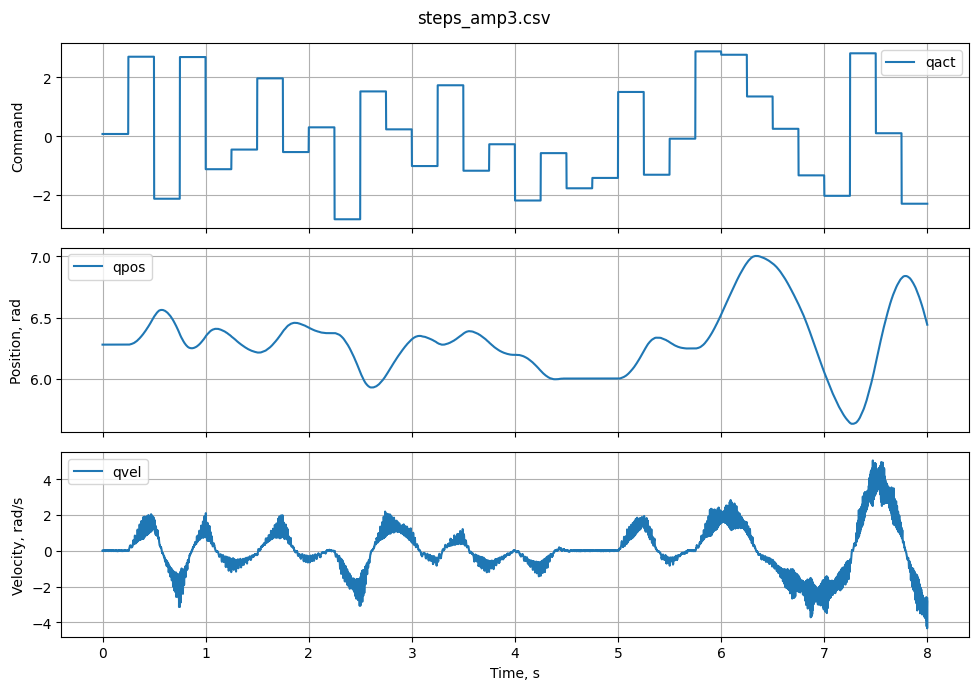

In [9]:
if csv_paths:
    preview_path = csv_paths[-1]
    preview_df = pd.read_csv(preview_path)

    fig, ax = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
    ax[0].plot(preview_df["time_s"], preview_df["qact"], label="qact")
    ax[0].set_ylabel("Command")

    ax[1].plot(preview_df["time_s"], preview_df["qpos"], label="qpos")
    ax[1].set_ylabel("Position, rad")

    ax[2].plot(preview_df["time_s"], preview_df["qvel"], label="qvel")
    ax[2].set_ylabel("Velocity, rad/s")
    ax[2].set_xlabel("Time, s")

    for axis in ax:
        axis.grid()
        axis.legend()

    fig.suptitle(preview_path.name)
    plt.tight_layout()
    plt.show()

Rows: 64000
qvel range: [-17.553, 17.954] rad/s
qact range: [-8.000, 8.000]
Occupied bins: 346 / 1600 (21.6%)
Near velocity limit: 0 samples (0.00%)


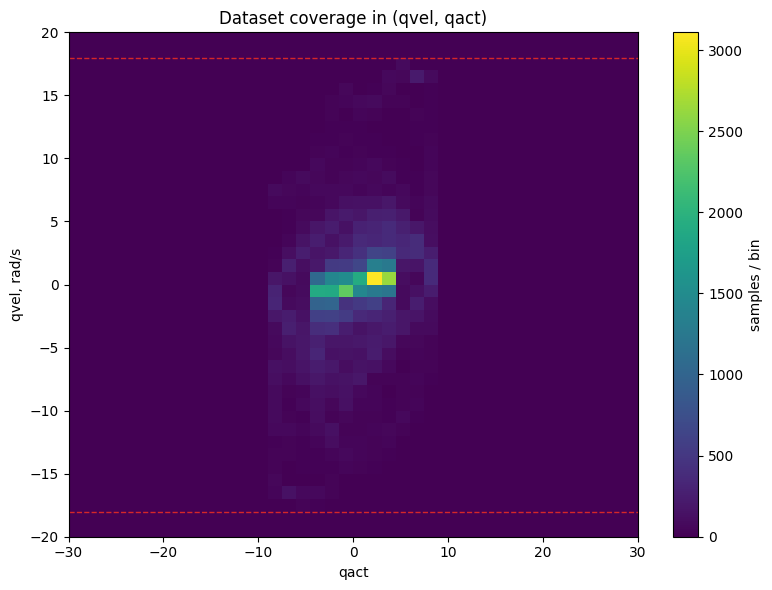

In [10]:
def load_dataset_frames(paths: list[Path]) -> pd.DataFrame:
    frames = []
    for path in paths:
        df = validate_dataset_csv(path).copy()
        df["run"] = path.stem
        frames.append(df)
    if not frames:
        return pd.DataFrame(columns=REQUIRED_COLUMNS + ["run"])
    return pd.concat(frames, ignore_index=True)


def plot_qvel_qact_coverage(
    df: pd.DataFrame,
    qvel_range: tuple[float, float] = (-QVEL_FEEDBACK_LIMIT, QVEL_FEEDBACK_LIMIT),
    qact_range: tuple[float, float] = (-MAX_ABS_COMMAND, MAX_ABS_COMMAND),
    qvel_bins: int = 40,
    qact_bins: int = 40,
) -> None:
    if df.empty:
        print("No dataset rows available for coverage plot.")
        return

    hist, qvel_edges, qact_edges = np.histogram2d(
        df["qvel"].to_numpy(),
        df["qact"].to_numpy(),
        bins=[qvel_bins, qact_bins],
        range=[qvel_range, qact_range],
    )
    occupied = hist > 0
    occupancy_pct = 100.0 * occupied.mean()

    near_qvel_limit = df["qvel"].abs() >= QVEL_WARNING_LIMIT
    print(f"Rows: {len(df)}")
    print(f"qvel range: [{df['qvel'].min():.3f}, {df['qvel'].max():.3f}] rad/s")
    print(f"qact range: [{df['qact'].min():.3f}, {df['qact'].max():.3f}]")
    print(f"Occupied bins: {occupied.sum()} / {occupied.size} ({occupancy_pct:.1f}%)")
    print(f"Near velocity limit: {near_qvel_limit.sum()} samples ({100.0 * near_qvel_limit.mean():.2f}%)")

    fig, ax = plt.subplots(figsize=(8, 6))
    mesh = ax.pcolormesh(qact_edges, qvel_edges, hist, shading="auto")
    fig.colorbar(mesh, ax=ax, label="samples / bin")
    ax.axhline(QVEL_WARNING_LIMIT, color="tab:red", linestyle="--", linewidth=1)
    ax.axhline(-QVEL_WARNING_LIMIT, color="tab:red", linestyle="--", linewidth=1)
    ax.set_xlabel("qact")
    ax.set_ylabel("qvel, rad/s")
    ax.set_title("Dataset coverage in (qvel, qact)")
    plt.tight_layout()
    plt.show()


coverage_df = load_dataset_frames(csv_paths)
plot_qvel_qact_coverage(coverage_df)